In [49]:
# %%
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

#v1 - rmse from optimization
#v2 - rmse of dTi from val
#v3 - remse from optimization (updated weights
# --- paths (edit if needed) ---
PARAMS_CSV = "trained_params_allhomes_fixedweights_linearstyle_v3.csv"

Q_STREAMS_PARQUET = "retrieved_weather_data/q_streams_30min.parquet"
#DETACHED_PARQUET  = "training_data/data_detached_with_weather.parquet"
# (or your merged file) e.g.
DETACHED_PARQUET = "retrieved_weather_data/merged_data_final_homes.parquet"

# validation settings
WEEK_DAYS = 7
DELTA_T_HOURS = 0.5          # 30-min
MAX_WEEK_SEARCH_DAYS = 365   # how far forward we’ll search after training end
MAX_SHIFT_TRIES = MAX_WEEK_SEARCH_DAYS  # shift forward by 1 day each try
INTERP_LIMIT_STEPS = 4       # short-gap interpolation limit (4*30min = 2 hours)

print("Using:", PARAMS_CSV)


Using: trained_params_allhomes_fixedweights_linearstyle_v3.csv


In [50]:
# %%
def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")

def _has_col(df, name):
    return name in df.columns


In [51]:
# %%
# %%
def read_q_exact_30min(df_train_q_exact: pd.DataFrame,
                       id_use,
                       t_start: pd.Timestamp,
                       t_end: pd.Timestamp) -> pd.DataFrame:
    """
    df_train_q_exact: index = Timestamp (30-min)
      columns = MultiIndex [Property_ID, variable]
        variable in {"Q_hp_total","Q_immersion","Q_dhw","Q_hp_sc","Q_total"}

    Returns: single-home df with flat columns + Q_spc_exact and Q_dhw_exact (if possible).
    """
    df_win = df_train_q_exact.loc[t_start:t_end]

    if not isinstance(df_win.columns, pd.MultiIndex):
        raise ValueError("Expected MultiIndex columns [Property_ID, variable].")

    if id_use not in df_win.columns.get_level_values(0):
        raise KeyError(f"id_use={id_use} not found in df_train_q_exact columns.")

    df_id = df_win.loc[:, (id_use, slice(None))].copy()
    df_id.columns = df_id.columns.droplevel(0)

    if "Q_dhw" in df_id.columns:
        df_id["Q_dhw_exact"] = df_id["Q_dhw"]

    if "Q_total" in df_id.columns and "Q_dhw" in df_id.columns:
        df_id["Q_spc_exact"] = df_id["Q_total"] - df_id["Q_dhw"]

    return df_id



In [52]:

# %%
df_params = pd.read_csv(PARAMS_CSV)

df_detached = pd.read_parquet(DETACHED_PARQUET)
df_q_exact_all = pd.read_parquet(Q_STREAMS_PARQUET)

print("params rows:", len(df_params))
print("detached rows:", len(df_detached))

# Ensure datetime index for df_detached subset operations
if "Timestamp" in df_detached.columns:
    df_detached["Timestamp"] = pd.to_datetime(df_detached["Timestamp"])
    df_detached = df_detached.set_index("Timestamp")

df_detached = df_detached.sort_index()

# Parse dates in params (train_start/train_end may have slightly different names)
train_start_col = _pick_col(df_params, ["train_start", "t_start_train", "t_start"])
train_end_col   = _pick_col(df_params, ["train_end", "t_end_train", "t_end"])

df_params[train_start_col] = pd.to_datetime(df_params[train_start_col])
df_params[train_end_col]   = pd.to_datetime(df_params[train_end_col])

id_col = _pick_col(df_params, ["Property_ID", "property_id", "id_use", "ID"])
print("ID col:", id_col, "| train_start:", train_start_col, "| train_end:", train_end_col)




params rows: 150
detached rows: 8934465
ID col: Property_ID | train_start: train_start | train_end: train_end


In [53]:
# %%
def build_df_home(df_detached, id_use):
    df_home = df_detached[df_detached["Property_ID"] == id_use].copy()
    df_home = df_home.sort_index()

    # Engineer columns used by your model (from your pasted script)
    # If any base columns are missing in your parquet, adjust here.
    df_home["Heat_Pump_Energy_Output_Diff"] = df_home["Heat_Pump_Energy_Output"].diff()
    df_home["Internal_Temperature_Diff"] = df_home["Internal_Air_Temperature"].diff()
    df_home["Internal_Ambient_Temperature_Diff"] = (
        df_home["temp"] - df_home["Internal_Air_Temperature"]
    )

    # Interpolate short gaps on numeric columns
    num_cols = df_home.select_dtypes(include=["number"]).columns
    df_home[num_cols] = df_home[num_cols].interpolate(
        method="time", limit=INTERP_LIMIT_STEPS, limit_direction="both"
    )

    # Drop remaining NaNs required for the model
    must = [
        "Internal_Air_Temperature",
        "temp",
        "Internal_Ambient_Temperature_Diff",
        "Internal_Temperature_Diff",
        "solarradiation",
    ]
    # Heat_Pump_Energy_Output_Diff not strictly needed for validation, but keep if present
    for c in must:
        if c not in df_home.columns:
            raise KeyError(f"Missing required column in df_home: {c}")

    df_home = df_home.dropna(subset=must)
    return df_home


In [54]:
# %%
def next_midnight(ts: pd.Timestamp) -> pd.Timestamp:
    ts = pd.Timestamp(ts)
    # go to next day midnight if not already exactly midnight
    if ts.hour == 0 and ts.minute == 0 and ts.second == 0:
        return ts
    return (ts.normalize() + pd.Timedelta(days=1))

def find_validation_week(
    id_use,
    df_home,
    df_q_exact_all,
    train_end: pd.Timestamp,
    week_days=WEEK_DAYS,
    max_shift_tries=MAX_SHIFT_TRIES,
):
    """
    Choose a 7-day window strictly AFTER train_end that has:
      - enough df_home points
      - full Q_spc_exact alignment (no NaNs after reindex)
    Strategy:
      start at next midnight after train_end, then shift forward 1 day until valid.
    """
    t0 = next_midnight(train_end + pd.Timedelta(minutes=30))  # ensure strictly outside
    week = pd.Timedelta(days=week_days) - pd.Timedelta(minutes=30)
    need_pts = int((24 * week_days) / DELTA_T_HOURS)  # e.g., 336 for 7 days at 30-min

    for shift in range(max_shift_tries):
        start = t0 + pd.Timedelta(days=shift)
        end = start + week

        df_week = df_home.loc[start:end].copy()
        if len(df_week) < need_pts:
            continue

        # exact q streams for same window
        try:
            df_q_week = read_q_exact_30min(df_q_exact_all, id_use, start, end)
        except Exception:
            continue

        if "Q_spc_exact" not in df_q_week.columns:
            continue

        # Align q to df_week index
        df_q_aligned = df_q_week.reindex(df_week.index)

        if df_q_aligned["Q_spc_exact"].isna().any():
            continue

        return start, end, df_week, df_q_aligned

    raise RuntimeError(
        f"Could not find a valid {week_days}-day validation week for home {id_use} "
        f"after train_end={train_end} within {max_shift_tries} day-shifts."
    )


In [55]:
def find_validation_month(
    id_use,
    df_home,
    df_q_exact_all,
    train_end: pd.Timestamp,
    month_days: int = 30,
    max_shift_tries: int = MAX_SHIFT_TRIES,
):
    """
    Choose a ~month window strictly AFTER train_end that has:
      - enough df_home points
      - full Q_spc_exact alignment (no NaNs after reindex)
    Strategy:
      start at next midnight after train_end, then shift forward 1 day until valid.

    Returns:
      start, end, df_month, df_q_aligned
    """
    # ensure strictly outside training window
    t0 = next_midnight(train_end + pd.Timedelta(minutes=30))

    horizon = pd.Timedelta(days=month_days) - pd.Timedelta(minutes=30)
    need_pts = int((24 * month_days) / DELTA_T_HOURS)  # e.g., 30 days * 48 = 1440

    for shift in range(max_shift_tries):
        start = t0 + pd.Timedelta(days=shift)
        end = start + horizon

        df_month = df_home.loc[start:end].copy()
        if len(df_month) < need_pts:
            continue

        # exact q streams for same window
        try:
            df_q_month = read_q_exact_30min(df_q_exact_all, id_use, start, end)
        except Exception:
            continue



        if "Q_spc_exact" not in df_q_month.columns:
            continue

        # Align q to df_month timeline (strict)
        df_q_aligned = df_q_month.reindex(df_month.index)

        # must be fully observed
        if df_q_aligned["Q_spc_exact"].isna().any():
            continue

        return start, end, df_month, df_q_aligned

    raise RuntimeError(
        f"Could not find a valid {month_days}-day validation month for home {id_use} "
        f"after train_end={train_end} within {max_shift_tries} day-shifts."
    )


In [56]:
# %%
def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[mask] - b[mask]) ** 2)))

def simulate_week(params_row: pd.Series, df_week: pd.DataFrame, df_q_week_aligned: pd.DataFrame, delta_t_hours=0.5):
    """
    Returns:
      - q_real, q_hat_sim (implied from model + measured Ti diffs)
      - Ti_sim_free: simulate Ti using q_real (free-run)
      - Ti_sim_reinit: simulate Ti using q_real with re-init at midnight
    """

    # --- parameters ---
    C   = float(params_row["C"])
    R_a = float(params_row["R_a"])
    w_s = float(params_row.get("w_s", 0.0))

    # optional terms
    w_const = float(params_row["w"]) if "w" in params_row.index else 0.0
    w_n     = float(params_row["w_n"]) if "w_n" in params_row.index else 0.0

    L = len(df_week) - 1
    if L <= 0:
        raise RuntimeError("Week slice too short.")

    # exogenous vectors (length L)
    delta_T_a = df_week["Internal_Ambient_Temperature_Diff"].iloc[:-1].to_numpy(dtype=float)
    q_solar   = df_week["solarradiation"].iloc[:-1].to_numpy(dtype=float)

    # night flag if available (else zeros)
    if "is_night" in df_week.columns:
        idx_night = df_week["is_night"].iloc[:-1].fillna(0).astype(int).to_numpy()
    else:
        idx_night = np.zeros(L, dtype=int)

    # measured delta_T_i (length L), consistent with your training convention
    delta_T_i = (df_week["Internal_Air_Temperature"].diff().iloc[1:].to_numpy(dtype=float) / delta_t_hours)

    # exact "real" q for plotting (length L)
    q_real = df_q_week_aligned["Q_spc_exact"].iloc[:-1].to_numpy(dtype=float)

    # ---- implied q_hat_sim (length L) ----
    # Keep the same “spirit” as your pasted script, but allow w_n if present.
    # baseline (your pasted form): q_hat = C*dT - (dTa/Ra)*dt - w_s*q_solar - w*dt
    q_hat_sim = (delta_T_i * C
                 - (delta_T_a / R_a) * delta_t_hours
                 - w_s * q_solar
                 - w_const * delta_t_hours
                 - w_n * idx_night)  # night-bias as additive heat term (no dt), consistent w/ idx_night usage

    # simulate Ti with q_real (this is what you requested)
    q_opt = q_real.copy()

    time_idx_state = df_week.index[1:]  # length L
    Ti_meas_state  = df_week["Internal_Air_Temperature"].iloc[1:].to_numpy(dtype=float)

    # consistent with your script’s update style
    delta_T_i_sim = (
        (delta_T_a / R_a) * delta_t_hours
        + q_opt
        + w_s * q_solar
        + w_const * delta_t_hours
        + w_n * idx_night
    ) / C

    Ti_sim_free   = np.zeros(L, dtype=float)
    Ti_sim_reinit = np.zeros(L, dtype=float)

    Ti_prev_free   = float(df_week["Internal_Air_Temperature"].iloc[0])
    Ti_prev_reinit = float(df_week["Internal_Air_Temperature"].iloc[0])

    for k, t in enumerate(time_idx_state):
        # free-run
        Ti_sim_free[k] = Ti_prev_free + delta_T_i_sim[k] * delta_t_hours
        Ti_prev_free = Ti_sim_free[k]

        # daily re-init at midnight (before applying update)
        if (t.hour == 0) and (t.minute == 0):
            if t in df_week.index:
                Ti_prev_reinit = float(df_week.loc[t, "Internal_Air_Temperature"])

        Ti_sim_reinit[k] = Ti_prev_reinit + delta_T_i_sim[k] * delta_t_hours
        Ti_prev_reinit = Ti_sim_reinit[k]

    # RMSEs
    rmse_q_week   = rmse(q_hat_sim, q_real)
    rmse_T_free   = rmse(Ti_sim_free, Ti_meas_state)
    rmse_T_reinit = rmse(Ti_sim_reinit, Ti_meas_state)

    return {
        "L": L,
        "time_q": df_week.index[:-1],
        "time_state": time_idx_state,
        "q_real": q_real,
        "q_hat_sim": q_hat_sim,
        "Ti_meas": Ti_meas_state,
        "Ti_sim_free": Ti_sim_free,
        "Ti_sim_reinit": Ti_sim_reinit,
        "rmse_q_week": rmse_q_week,
        "rmse_T_free": rmse_T_free,
        "rmse_T_reinit": rmse_T_reinit,
    }


In [57]:
# %%
def run_allhomes_validation(df_params, df_detached, df_q_exact_all):
    rows = []

    for _, prow in df_params.iterrows():
        id_use = prow[id_col]
        train_end = prow[train_end_col]

        # Some IDs might be numeric vs string across datasets; normalize by trying both
        # (most of your data uses df_detached["Property_ID"] exactly, so keep as-is)
        try:
            df_home = build_df_home(df_detached, id_use)
        except Exception:
            # try casting
            try:
                df_home = build_df_home(df_detached, str(id_use))
                id_use = str(id_use)
            except Exception:
                continue

        try:
            week_start, week_end, df_week, df_q_aligned = find_validation_month(
                id_use=id_use,
                df_home=df_home,
                df_q_exact_all=df_q_exact_all,
                train_end=train_end,
            )
        except Exception:
            continue

        try:
            sim = simulate_week(prow, df_week, df_q_aligned, delta_t_hours=DELTA_T_HOURS)
        except Exception:
            continue

        rows.append({
            "Property_ID": id_use,
            "train_end": train_end,
            "val_week_start": week_start,
            "val_week_end": week_end,
            "rmse_q_week": sim["rmse_q_week"],
            "rmse_T_free": sim["rmse_T_free"],
            "rmse_T_reinit": sim["rmse_T_reinit"],
            "n_points": len(df_week),
        })

    return pd.DataFrame(rows)

In [58]:
# %%
from collections import Counter

def debug_validation_failures(df_params, df_detached, df_q_exact_all, max_show=10):
    fails = Counter()
    examples = []

    # quick sanity: what does q_streams look like?
    print("q_streams index type:", type(df_q_exact_all.index))
    print("q_streams index sample:", df_q_exact_all.index[:3])
    print("q_streams columns is MultiIndex:", isinstance(df_q_exact_all.columns, pd.MultiIndex))
    if isinstance(df_q_exact_all.columns, pd.MultiIndex):
        print("q_streams property_id dtype sample:", df_q_exact_all.columns.get_level_values(0)[:5])

    # sanity: df_detached time index
    print("detached index type:", type(df_detached.index))
    print("detached index sample:", df_detached.index[:3])

    for k, (_, prow) in enumerate(df_params.iterrows()):
        id_use = prow[id_col]
        train_end = prow[train_end_col]

        try:
            # try both id types
            try:
                df_home = build_df_home(df_detached, id_use)
                id_ok = id_use
            except Exception:
                df_home = build_df_home(df_detached, str(id_use))
                id_ok = str(id_use)

        except KeyError as e:
            fails["missing_required_columns_in_detached"] += 1
            if len(examples) < max_show:
                examples.append((id_use, "missing_required_columns_in_detached", str(e)))
            continue
        except Exception as e:
            fails["cannot_build_df_home"] += 1
            if len(examples) < max_show:
                examples.append((id_use, "cannot_build_df_home", f"{type(e).__name__}: {e}"))
            continue

        # try find week
        try:
            _ = find_validation_month(
                id_use=id_ok,
                df_home=df_home,
                df_q_exact_all=df_q_exact_all,
                train_end=train_end,
            )
        except KeyError as e:
            fails["id_not_in_q_streams"] += 1
            if len(examples) < max_show:
                examples.append((id_ok, "id_not_in_q_streams", str(e)))
            continue
        except RuntimeError as e:
            fails["no_valid_week_found"] += 1
            if len(examples) < max_show:
                examples.append((id_ok, "no_valid_week_found", str(e)))
            continue
        except Exception as e:
            fails["find_week_other_error"] += 1
            if len(examples) < max_show:
                examples.append((id_ok, "find_week_other_error", f"{type(e).__name__}: {e}"))
            continue

        # if we got here, at least one home passed week-finding
        print("SUCCESS: found at least one valid week for home:", id_ok)
        break

    print("\nFailure counts:")
    for k, v in fails.most_common():
        print(f"  {k}: {v}")

    print("\nExamples:")
    for ex in examples:
        print(" ", ex)

# run debug
debug_validation_failures(df_params, df_detached, df_q_exact_all, max_show=15)



q_streams index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
q_streams index sample: DatetimeIndex(['2020-10-26 00:00:00', '2020-10-26 00:30:00',
               '2020-10-26 01:00:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
q_streams columns is MultiIndex: True
q_streams property_id dtype sample: Index(['EOH0005', 'EOH0005', 'EOH0005', 'EOH0005', 'EOH0005'], dtype='object', name='Property_ID')
detached index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
detached index sample: DatetimeIndex(['2020-10-26 00:00:00', '2020-10-26 00:00:00',
               '2020-10-26 00:30:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
SUCCESS: found at least one valid week for home: EOH0005

Failure counts:

Examples:


In [59]:
df_val_results = run_allhomes_validation(df_params, df_detached, df_q_exact_all)

In [60]:
df_val_results

,Property_ID,train_end,val_week_start,val_week_end,rmse_q_week,rmse_T_free,rmse_T_reinit,n_points
0,EOH0005,2022-12-31 23:59:59,2023-01-02,2023-01-31 23:30:00,2.148595,10.405294,1.147105,1440
1,EOH0026,2022-12-31 23:59:59,2023-01-02,2023-01-31 23:30:00,0.574228,15.418196,0.536252,1440
2,EOH0033,2022-12-31 23:59:59,2023-04-02,2023-05-01 23:30:00,2.127535,26.621498,1.634626,1440
3,EOH0065,2022-12-31 23:59:59,2023-02-14,2023-03-15 23:30:00,1.476702,5.934452,0.582261,1440
4,EOH0066,2022-12-31 23:59:59,2023-03-19,2023-04-17 23:30:00,0.792067,5.139980,0.797332,1440
...,...,...,...,...,...,...,...,...
138,EOH3089,2022-12-31 23:59:59,2023-03-07,2023-04-05 23:30:00,2.577060,14.155488,0.528346,1440
139,EOH3120,2022-12-31 23:59:59,2023-01-02,2023-01-31 23:30:00,0.974807,17.034201,0.902515,1440
140,EOH3154,2021-12-31 23:59:59,2022-01-02,2022-01-31 23:30:00,0.794749,2.144553,0.584858,1440
141,EOH3167,2022-12-31 23:59:59,2023-01-02,2023-01-31 23:30:00,1.263978,6.222828,0.733368,1440


{'whiskers': [<matplotlib.lines.Line2D at 0x312676840>,
 'caps': [<matplotlib.lines.Line2D at 0x312674170>,
 'boxes': [<matplotlib.lines.Line2D at 0x312677a70>],
 'medians': [<matplotlib.lines.Line2D at 0x312674aa0>],
 'fliers': [<matplotlib.lines.Line2D at 0x13d5b29f0>],
 'means': []}

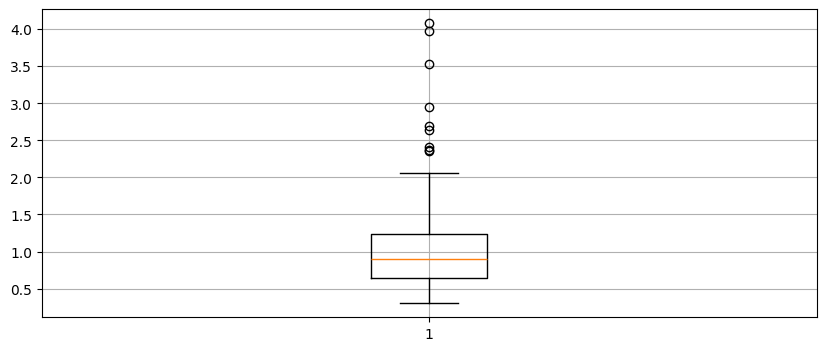

In [61]:
plt.boxplot(df_val_results["rmse_T_reinit"])

In [62]:

print("validated homes:", len(df_val_results))
display(df_val_results.head())

validated homes: 143


,Property_ID,train_end,val_week_start,val_week_end,rmse_q_week,rmse_T_free,rmse_T_reinit,n_points
0,EOH0005,2022-12-31 23:59:59,2023-01-02,2023-01-31 23:30:00,2.148595,10.405294,1.147105,1440
1,EOH0026,2022-12-31 23:59:59,2023-01-02,2023-01-31 23:30:00,0.574228,15.418196,0.536252,1440
2,EOH0033,2022-12-31 23:59:59,2023-04-02,2023-05-01 23:30:00,2.127535,26.621498,1.634626,1440
3,EOH0065,2022-12-31 23:59:59,2023-02-14,2023-03-15 23:30:00,1.476702,5.934452,0.582261,1440
4,EOH0066,2022-12-31 23:59:59,2023-03-19,2023-04-17 23:30:00,0.792067,5.139980,0.797332,1440


In [63]:

num = df_val_results.select_dtypes(include=[np.number])
display(num.describe())



,rmse_q_week,rmse_T_free,rmse_T_reinit,n_points
count,143.000000,143.000000,143.000000,143.0
mean,1.831680,15.039442,1.066964,1440.0
std,1.260854,16.244459,0.653983,0.0
min,0.309279,0.772789,0.301775,1440.0
25%,1.116998,5.691235,0.645779,1440.0
50%,1.422529,10.362379,0.893636,1440.0
75%,2.145092,18.175176,1.237923,1440.0
max,8.823657,117.624475,4.079388,1440.0


Plotting IDs: ['EOH0943', 'EOH0991', 'EOH1018', 'EOH1041', 'EOH1042', 'EOH1097', 'EOH1103', 'EOH1109', 'EOH1114', 'EOH1186']


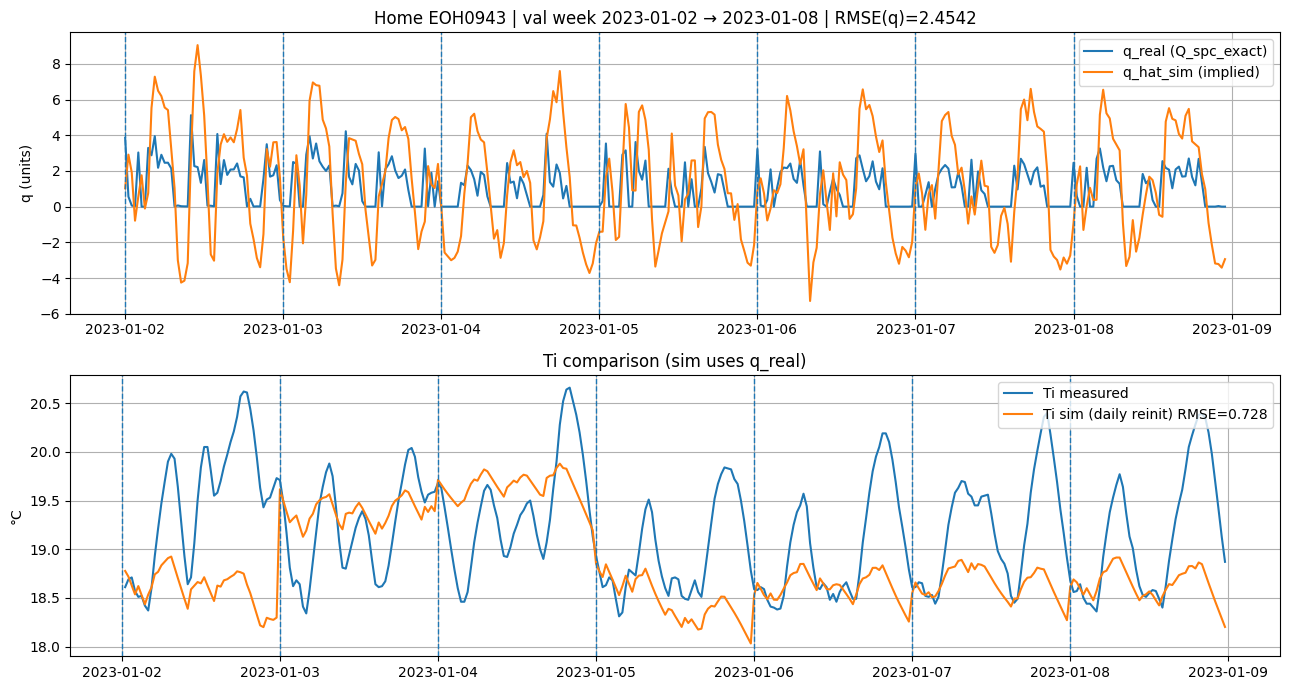

Skip home EOH0991: RuntimeError - Could not find a valid 7-day validation week for home EOH0991 after train_end=2022-12-31 23:59:59 within 365 day-shifts.


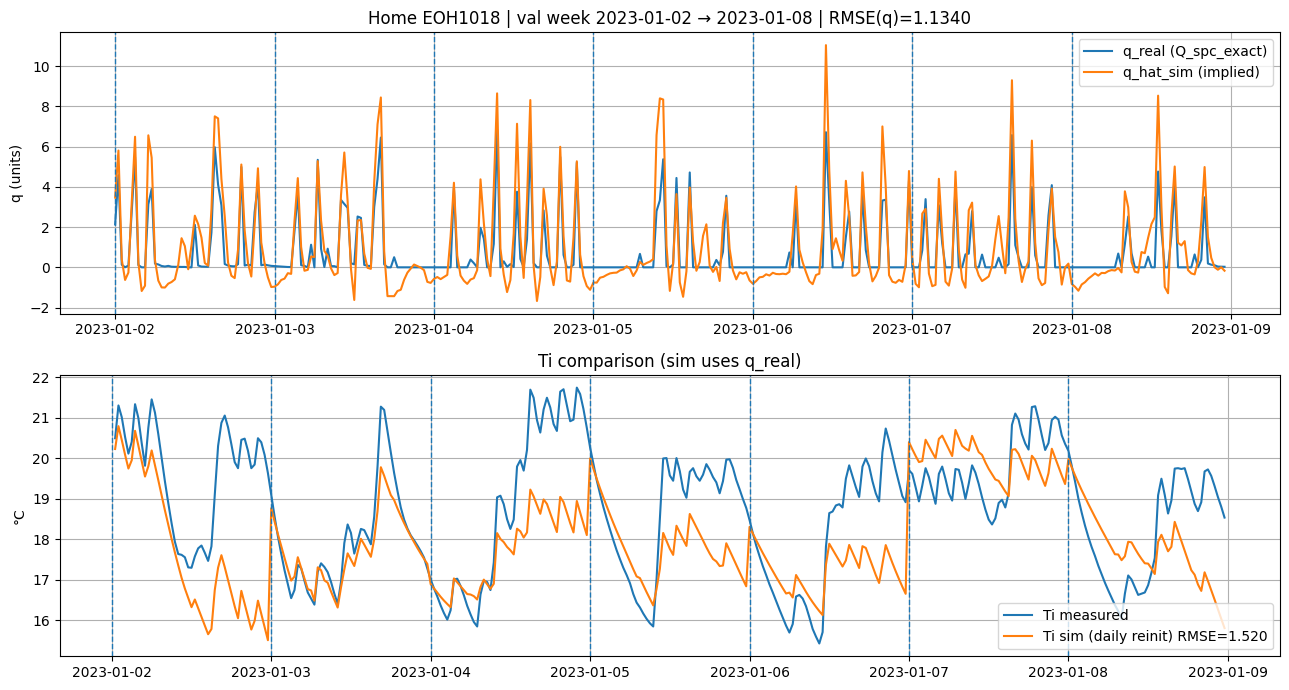

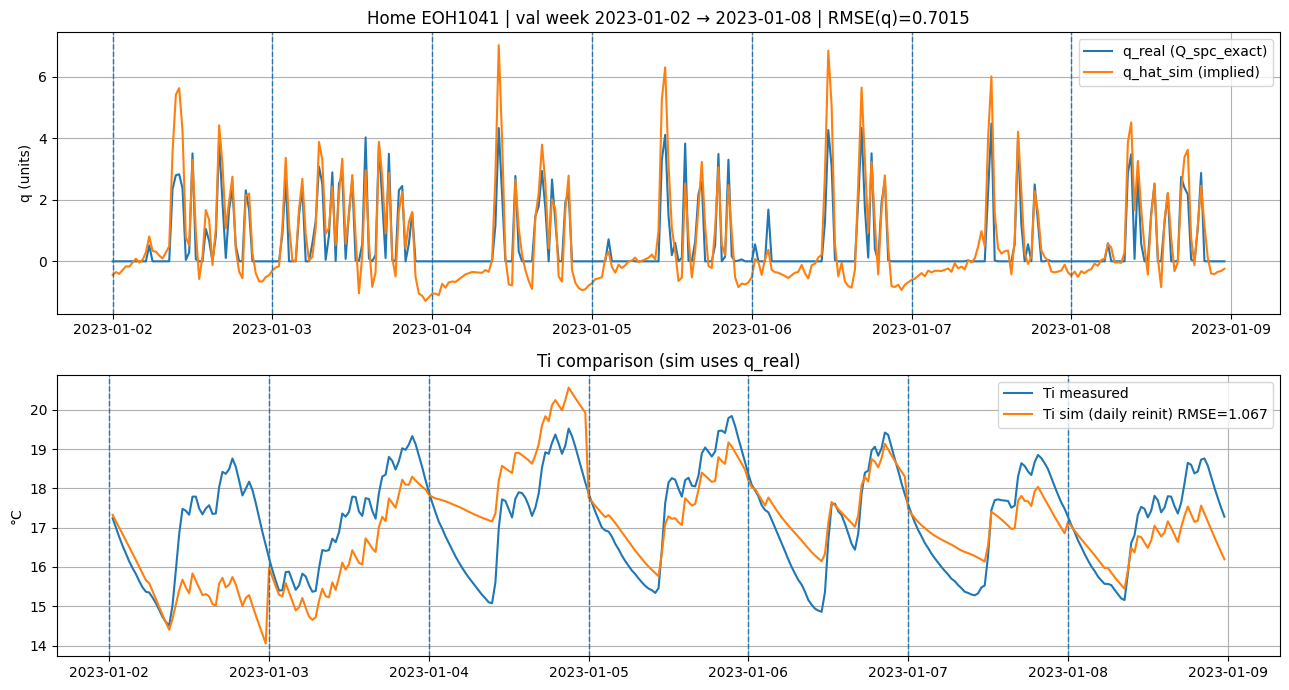

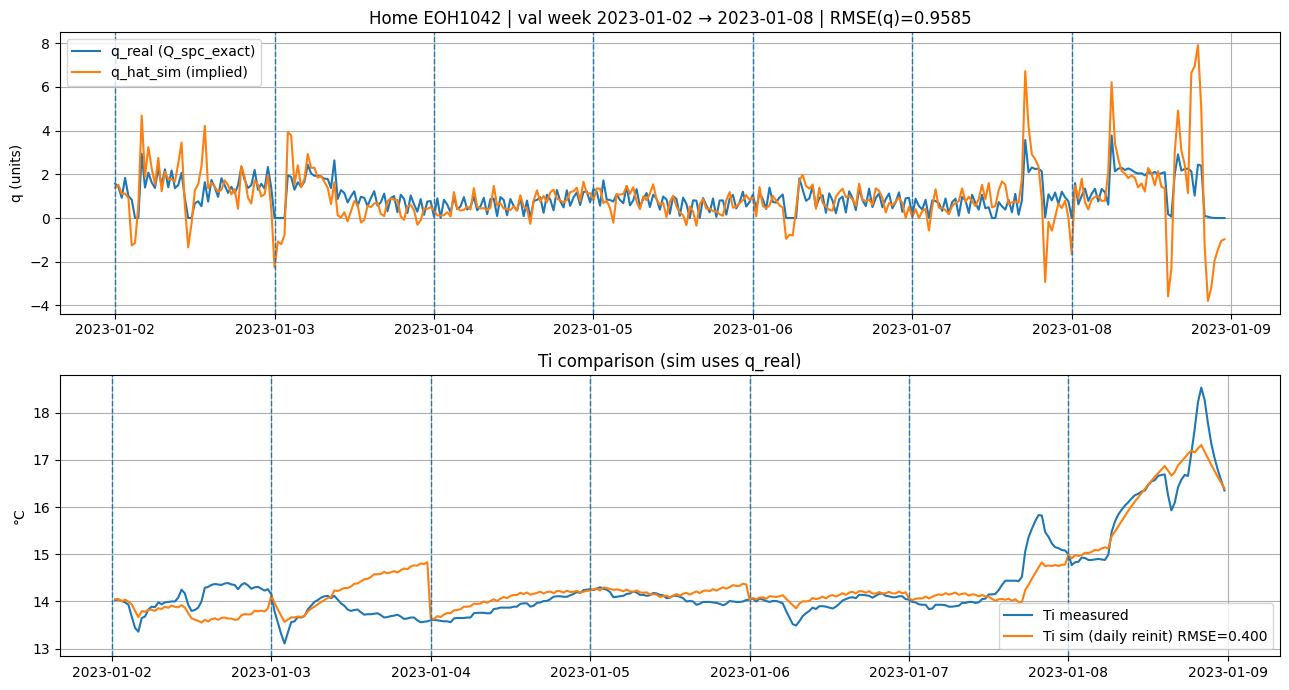

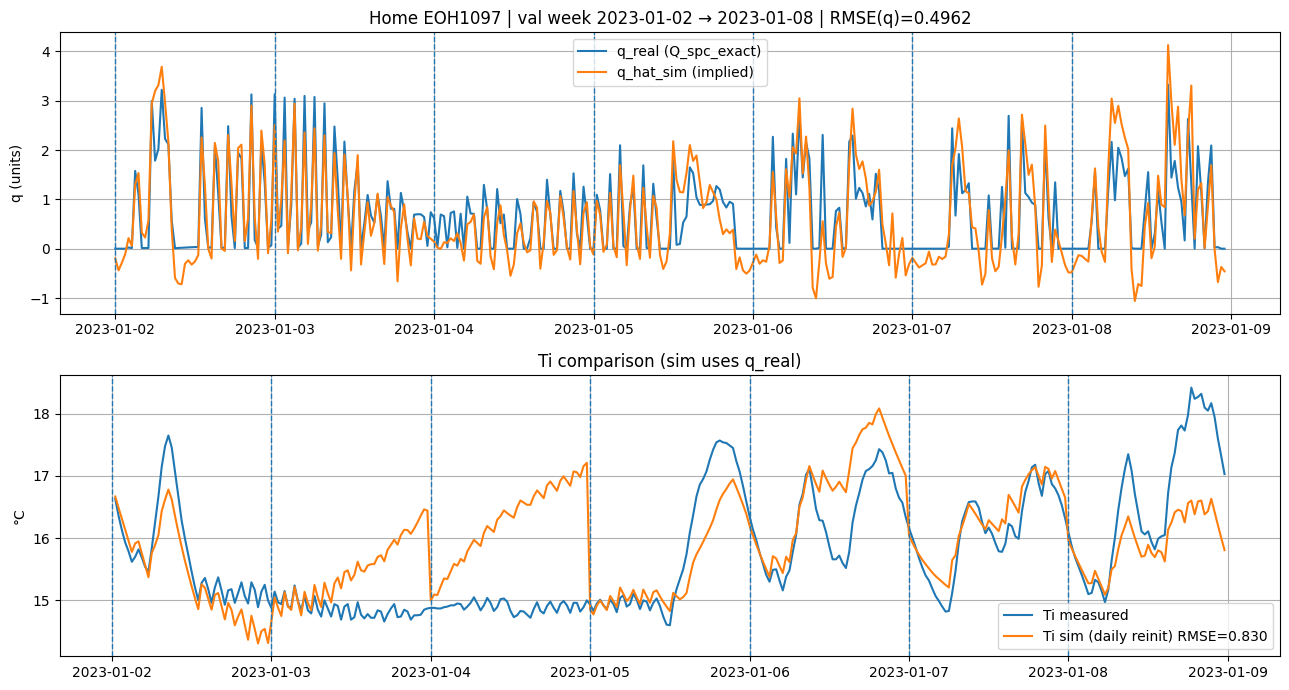

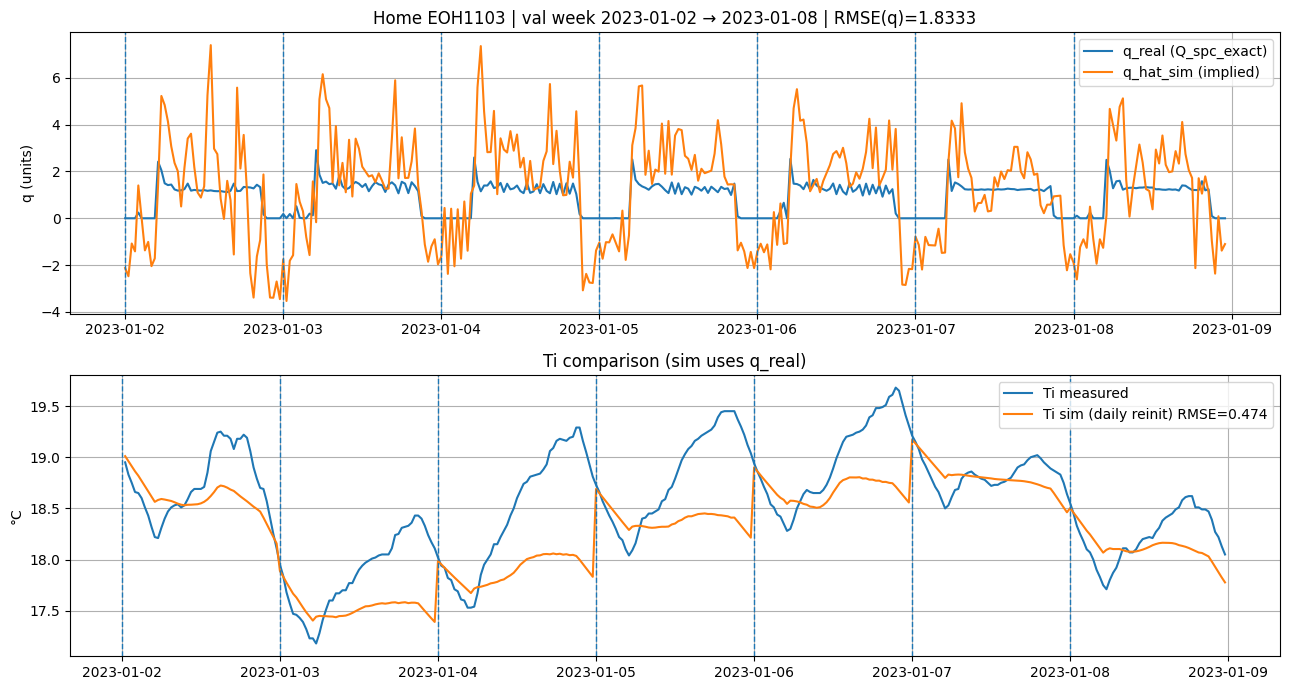

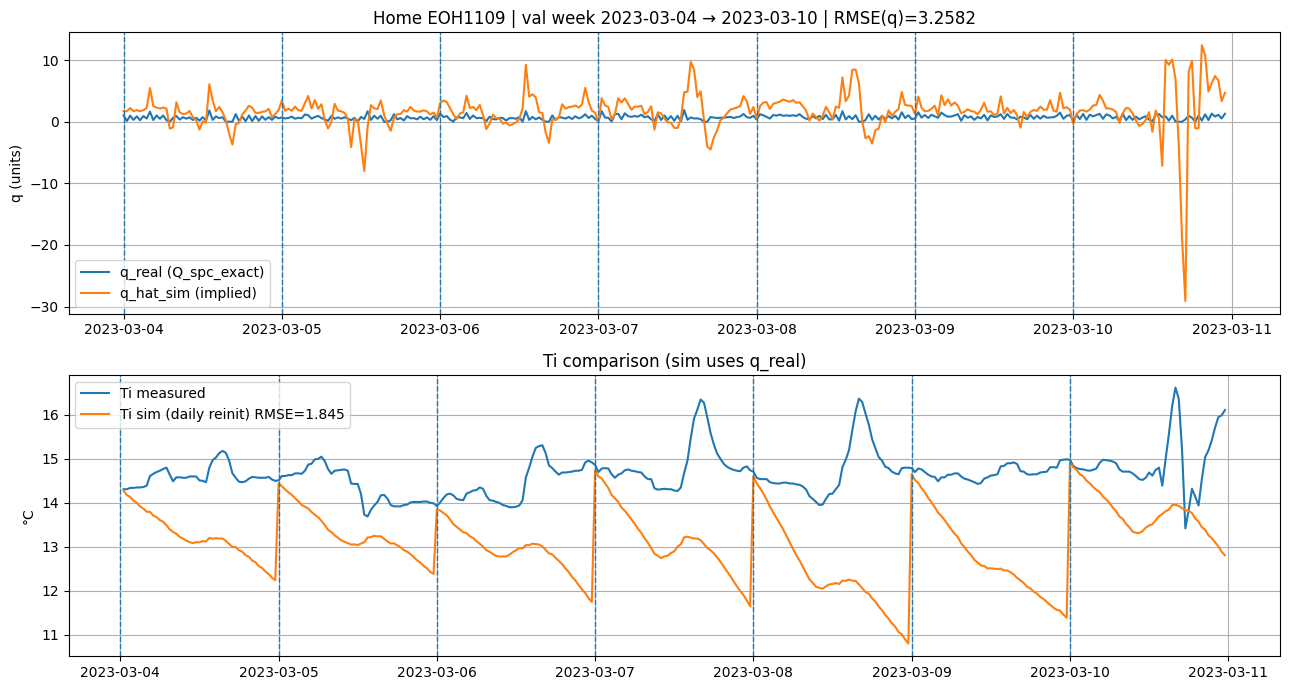

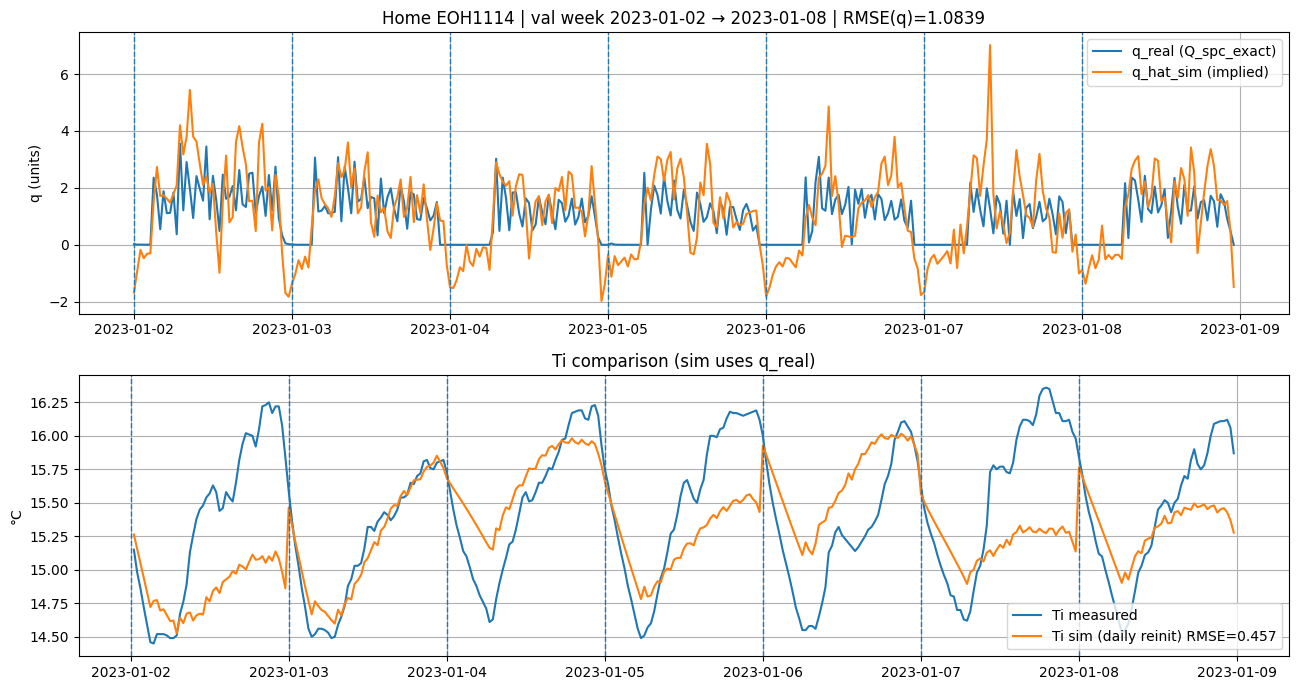

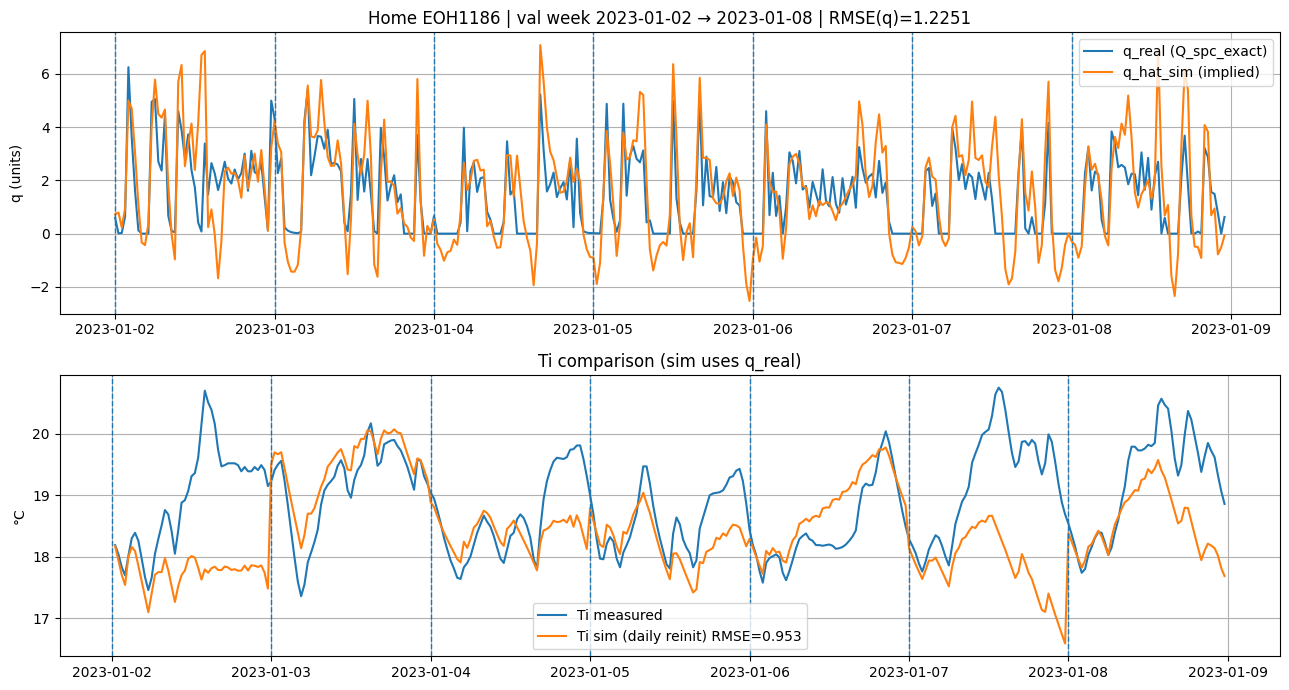

In [64]:
# %%
def plot_home_week(id_use, df_params, df_detached, df_q_exact_all):
    prow = df_params[df_params[id_col] == id_use].iloc[0]
    train_end = prow[train_end_col]

    df_home = build_df_home(df_detached, id_use)
    week_start, week_end, df_week, df_q_aligned = find_validation_week(
        id_use=id_use,
        df_home=df_home,
        df_q_exact_all=df_q_exact_all,
        train_end=train_end,
    )

    sim = simulate_week(prow, df_week, df_q_aligned, delta_t_hours=DELTA_T_HOURS)

    # midnight markers
    midnights = pd.date_range(df_week.index.min().normalize(),
                              df_week.index.max().normalize(),
                              freq="D")
    midnights = [t for t in midnights if (t >= df_week.index.min()) and (t <= df_week.index.max())]

    fig, (axq, axt) = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

    axq.plot(sim["time_q"], sim["q_real"], label="q_real (Q_spc_exact)")
    axq.plot(sim["time_q"], sim["q_hat_sim"], label="q_hat_sim (implied)")
    for t in midnights:
        axq.axvline(t, linestyle="--", linewidth=1)
    axq.set_ylabel("q (units)")
    axq.set_title(f"Home {id_use} | val week {week_start.date()} → {week_end.date()} | RMSE(q)={sim['rmse_q_week']:.4f}")
    axq.legend()

    axt.plot(sim["time_state"], sim["Ti_meas"], label="Ti measured")
    #axt.plot(sim["time_state"], sim["Ti_sim_free"], label=f"Ti sim
    # (free-run) RMSE={sim['rmse_T_free']:.3f}")
    axt.plot(sim["time_state"], sim["Ti_sim_reinit"], label=f"Ti sim (daily reinit) RMSE={sim['rmse_T_reinit']:.3f}")
    for t in midnights:
        axt.axvline(t, linestyle="--", linewidth=1)
    axt.set_ylabel("°C")
    axt.set_title("Ti comparison (sim uses q_real)")
    axt.legend()

    plt.tight_layout()
    plt.show()


def plot_block_of_10(start_idx=0):
    ids = df_params[id_col].iloc[start_idx:start_idx+10].tolist()
    print("Plotting IDs:", ids)

    for hid in ids:
        try:
            plot_home_week(hid, df_params, df_detached, df_q_exact_all)
        except Exception as e:
            print(f"Skip home {hid}: {type(e).__name__} - {e}")

# --- choose which block of 10 ---
plot_block_of_10(start_idx=50)


In [88]:
# %%
# --- additional RC-parameter methods (wide → long) ---
PARAMS_LIN_AGG = "trained_params_lin_regres_agg_v1.csv"
PARAMS_LIN_DIS = "trained_params_lin_regres_disag_v2.csv"

def read_params_wide(path):
    # CSV format:
    # rows = parameters (C, R_a, w_s, w_n, train_start, ...)
    # columns = Property_IDs
    df = pd.read_csv(path)

    # first column is parameter name
    param_col = df.columns[0]
    df = df.set_index(param_col).T
    df.index.name = "Property_ID"

    # numeric params
    for c in ["C", "R_a", "w_s", "w", "w_n"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # datetime params (if present)
    for c in ["train_start", "train_end", "val_start", "val_end"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    return df.reset_index()

df_params_lin_agg = read_params_wide(PARAMS_LIN_AGG)
df_params_lin_dis = read_params_wide(PARAMS_LIN_DIS)

# ensure consistent ID dtype for window matching
df_params_lin_agg["Property_ID"] = df_params_lin_agg["Property_ID"].astype(str)
df_params_lin_dis["Property_ID"] = df_params_lin_dis["Property_ID"].astype(str)

print("Loaded alternative methods:",
      len(df_params_lin_agg), len(df_params_lin_dis))

print("Agg columns:", df_params_lin_agg.columns.tolist())
print("Dis columns:", df_params_lin_dis.columns.tolist())


Loaded alternative methods: 215 221
Agg columns: ['Property_ID', 'Floor Area', 'No_Storeys', 'Wall_Type', 'HP_Type', 'House_SAP', 'C', 'R_a', 'w_s', 'w_n', 'rmse', 'train_start', 'train_end', 'val_start', 'val_end']
Dis columns: ['Property_ID', 'Floor Area', 'No_Storeys', 'Wall_Type', 'HP_Type', 'House_SAP', 'C', 'R_a', 'w_s', 'w_n', 'rmse', 'train_start', 'train_end', 'val_start', 'val_end', 'missing_data']


In [89]:
# %%
def run_validation_given_windows(df_params, windows):
    """
    windows: dict {Property_ID: (start, end)}
    """
    rows = []

    for _, prow in df_params.iterrows():
        id_use = prow[id_col]
        if id_use not in windows:
            continue

        start, end = windows[id_use]

        try:
            df_home = build_df_home(df_detached, id_use)
            df_month = df_home.loc[start:end]

            df_q = read_q_exact_30min(df_q_exact_all, id_use, start, end)
            df_q = df_q.reindex(df_month.index)

            sim = simulate_week(prow, df_month, df_q, DELTA_T_HOURS)
        except Exception:
            continue

        rows.append({
            "Property_ID": id_use,
            "rmse_q": sim["rmse_q_week"],
            "rmse_T_free": sim["rmse_T_free"],
            "rmse_T_reinit": sim["rmse_T_reinit"],
            "n_points": len(df_month)
        })

    return pd.DataFrame(rows)


In [90]:
# %%
# windows used by the baseline (fixed-weights optimization)
val_windows = {
    r.Property_ID: (r.val_week_start, r.val_week_end)
    for _, r in df_val_results.iterrows()
}


In [91]:
# %%
df_val_opt = df_val_results.copy()
df_val_opt["method"] = "Optimization (fixed weights)"

df_val_lin_agg = run_validation_given_windows(df_params_lin_agg, val_windows)
df_val_lin_agg["method"] = "Linear regression (aggregated)"

df_val_lin_dis = run_validation_given_windows(df_params_lin_dis, val_windows)
df_val_lin_dis["method"] = "Linear regression (disaggregated)"

df_val_all = pd.concat(
    [df_val_opt, df_val_lin_agg, df_val_lin_dis],
    ignore_index=True
)

display(df_val_all.groupby("method")[["rmse_T_reinit", "rmse_q"]].describe())


rmse_T_reinit                                \
                                          count      mean       std       min   
method                                                                          
Linear regression (aggregated)            142.0  1.318435  1.152466  0.316101   
Linear regression (disaggregated)         143.0  1.322256  1.153588  0.316176   
Optimization (fixed weights)              143.0  1.066964  0.653983  0.301775   

                                                                           \
                                        25%       50%       75%       max   
method                                                                      
Linear regression (aggregated)     0.702869  0.986863  1.468068  8.550923   
Linear regression (disaggregated)  0.715302  0.978850  1.466055  8.508209   
Optimization (fixed weights)       0.645779  0.893636  1.237923  4.079388   

                                  rmse_q                                \
                                   count      mean       std       min   
method                                                                   
Linear regression (aggregated)     142.0  2.701511  6.999967  0.344452   
Linear regression (disaggregated)  143.0  2.190272  2.392667  0.343493   
Optimization (fixed weights)         0.0       NaN       NaN       NaN   

                                                                            
                                        25%       50%       75%        max  
method                                                                      
Linear regression (aggregated)     1.030011  1.474826  2.326966  80.779086  
Linear regression (disaggregated)  1.015616  1.483111  2.336687  16.238043  
Optimization (fixed weights)            NaN       NaN       NaN        NaN

<Figure size 900x400 with 0 Axes>

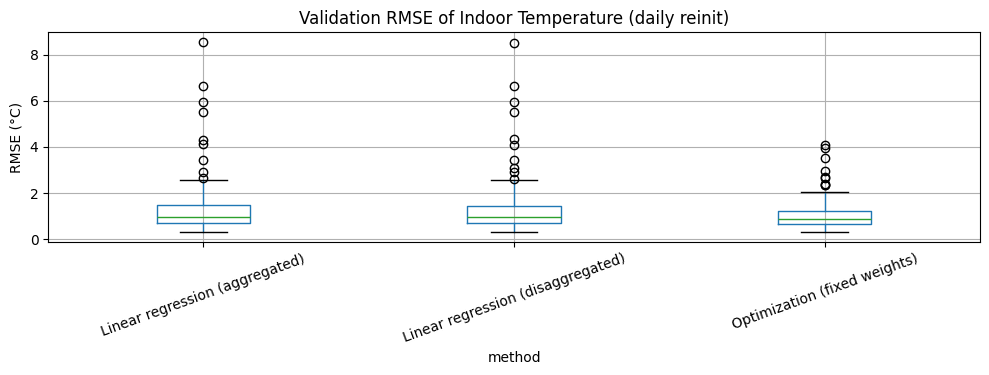

In [94]:
# %%
plt.figure(figsize=(9,4))
df_val_all.boxplot(
    column="rmse_T_reinit",
    by="method",
    grid=True,
    rot=20
)
plt.suptitle("")
plt.title("Validation RMSE of Indoor Temperature (daily reinit)")
plt.ylabel("RMSE (°C)")
plt.tight_layout()
#plt.ylim(0,3)
plt.show()


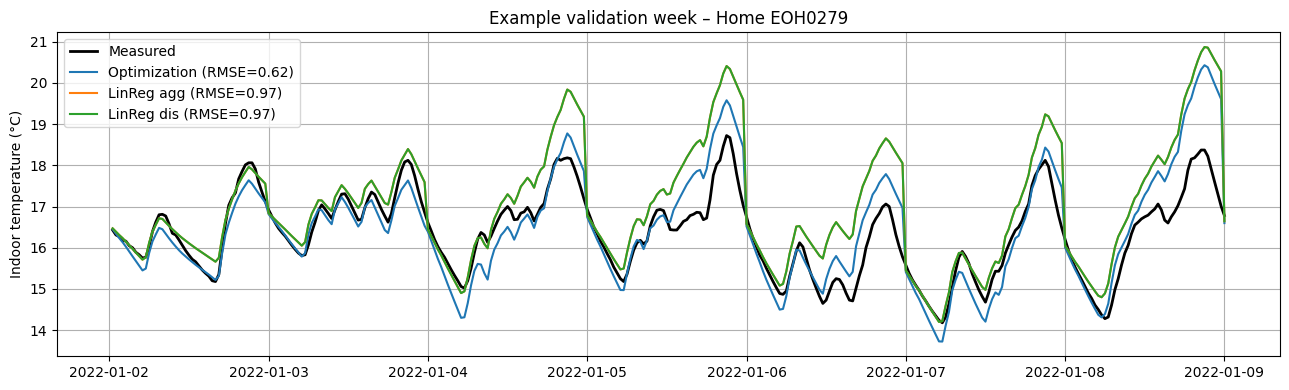

In [93]:
# %%
def plot_example_week_all_methods(id_use):
    # shared window
    start, end = val_windows[id_use]

    df_home = build_df_home(df_detached, id_use)
    df_week = df_home.loc[start:start + pd.Timedelta(days=7)]
    df_q = read_q_exact_30min(df_q_exact_all, id_use, df_week.index[0], df_week.index[-1])
    df_q = df_q.reindex(df_week.index)

    sims = {}

    for label, dfp in [
        ("Optimization", df_params),
        ("LinReg agg", df_params_lin_agg),
        ("LinReg dis", df_params_lin_dis),
    ]:
        prow = dfp[dfp[id_col] == id_use].iloc[0]
        sims[label] = simulate_week(prow, df_week, df_q, DELTA_T_HOURS)

    plt.figure(figsize=(13,4))
    plt.plot(
        sims["Optimization"]["time_state"],
        sims["Optimization"]["Ti_meas"],
        color="k", linewidth=2, label="Measured"
    )

    for k, s in sims.items():
        plt.plot(
            s["time_state"],
            s["Ti_sim_reinit"],
            label=f"{k} (RMSE={s['rmse_T_reinit']:.2f})"
        )

    plt.title(f"Example validation week – Home {id_use}")
    plt.ylabel("Indoor temperature (°C)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# pick a representative home
example_id = df_val_results["Property_ID"].iloc[15]
plot_example_week_all_methods(example_id)
